# 10 — Model explainability

`PROJECT_PLAN.md` Section 5 point 4. Explains the **exported** model
(`models/price_pipeline.pkl`) — a `RandomForestRegressor` on a `ColumnTransformer`,
trained on `log1p(price)`. Nothing is refit: `shap.TreeExplainer` reads the
fitted trees directly, and the global summary runs on the same training split
the model was fit on (`src.models.train.split_dataset`).

The insights notebook's standardised-linear-coefficient method is **not** ported —
it assumes a linear model and is meaningless for a forest.

**SHAP units.** SHAP values are in `log1p(price)` space: additive there
(`sum(shap) + base == model log-output`), and `expm1(log-output)` is the crore
price. They do *not* pass through `expm1` linearly, so per-feature contributions
are shown in log units and the price in crore separately. Sign and rank carry
over to price; magnitudes are log-space.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
warnings.simplefilter("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.models.explain import PriceExplainer
from src.models.train import load_dataset

ex = PriceExplainer()
print(f"base value: {ex.base_value_log:.4f} log  =  ~Rs {np.expm1(ex.base_value_log):.3f} Cr")
print("features:", ex.feature_names)

base value: 1.0467 log  =  ~Rs 1.848 Cr
features: ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room', 'sector', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category', 'property_type_house']


## 1. Global importance — impurity vs mean |SHAP|

Written to `reports/model/feature_importance.json` and
`reports/model/explainability_summary.md` for `docs/model_documentation.md` later.
`rf_impurity_importance` is fast but biased toward high-cardinality features
(`sector` has 104 levels); mean |SHAP| is the more trustworthy ranking.

In [2]:
report = ex.write_global_reports()

gi = pd.DataFrame(report["features"]).set_index("label")[["mean_abs_shap_log", "rf_impurity_importance"]]
gi = gi.sort_values("mean_abs_shap_log", ascending=False)
gi.round(4)

,mean_abs_shap_log,rf_impurity_importance
label,,
built_up_area,0.1698,0.3267
sector,0.1615,0.2452
bathroom,0.0761,0.1157
property_type (house=1),0.0702,0.0646
bedRoom,0.0623,0.1179
servant room,0.0347,0.0342
balcony,0.0260,0.0308
agePossession,0.0125,0.0189
furnishing_type,0.0118,0.0128


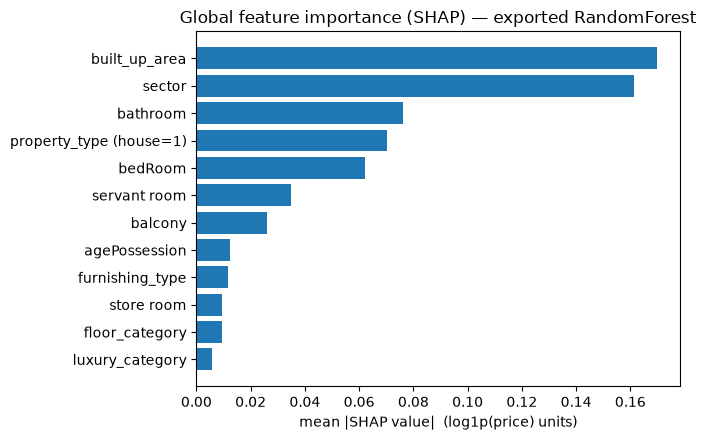

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = gi.sort_values("mean_abs_shap_log")
ax.barh(order.index, order["mean_abs_shap_log"])
ax.set_xlabel("mean |SHAP value|  (log1p(price) units)")
ax.set_title("Global feature importance (SHAP) — exported RandomForest")
plt.tight_layout()
plt.show()

## 2. Per-property explanations — 3 real rows

Three hand-picked real rows spanning the price range and both property types
(flat / flat / house). Not a by-price-proximity pick: the sub-Rs 1 Cr row was
vetted against source data — see `reports/model/explainability_summary.md`,
"Data-quality checks", for why the first candidate (row 33) was dropped.
`explain_property()` is what the app's prediction page will call.

In [4]:
X, y = load_dataset()

# (label, row index) — deliberate picks, low row vetted for data quality
PICKS = [
    ("~Rs 0.7 Cr  (2 BHK flat, Shree Vardhman Flora, sector 90)", 2757),
    ("~Rs 2 Cr    (3 BHK flat, sector 108)",                       6),
    ("~Rs 6 Cr    (9 BHK house, sector 12)",                       309),
]

def show(label, idx):
    row = X.loc[idx].to_dict()
    out = ex.explain_property(row, top_n=5)
    print("=" * 78)
    print(f"{label}   (row {idx})")
    print(f"  actual price     : Rs {y.loc[idx]:.2f} Cr")
    print(f"  predicted price  : Rs {out['predicted_price_cr']:.2f} Cr   "
          f"(base ~Rs {out['base_value_cr']:.2f} Cr)")
    print(f"  additivity resid : {out['additivity_residual_log']:.2e} log")
    print(f"  attributes       : { {k: row[k] for k in ['property_type','sector','bedRoom','bathroom','built_up_area','agePossession','luxury_category','floor_category']} }")
    print("  pushes price UP:")
    for c_ in out["pushed_up"]:
        print(f"    {c_['label']:<26} = {str(c_['input_value']):<16} shap_log +{c_['shap_log']:.3f}")
    print("  pushes price DOWN:")
    for c_ in out["pushed_down"]:
        print(f"    {c_['label']:<26} = {str(c_['input_value']):<16} shap_log {c_['shap_log']:.3f}")
    print()

for label, idx in PICKS:
    show(label, idx)

~Rs 0.7 Cr  (2 BHK flat, Shree Vardhman Flora, sector 90)   (row 2757)
  actual price     : Rs 0.70 Cr
  predicted price  : Rs 0.84 Cr   (base ~Rs 1.85 Cr)
  additivity resid : -3.33e-16 log
  attributes       : {'property_type': 'flat', 'sector': 'sector 90', 'bedRoom': 2.0, 'bathroom': 2.0, 'built_up_area': 1350.0, 'agePossession': 'New Property', 'luxury_category': 'Medium', 'floor_category': 'Mid Floor'}
  pushes price UP:
    balcony                    = 3                shap_log +0.015
    agePossession              = New Property     shap_log +0.004
  pushes price DOWN:
    sector                     = sector 90        shap_log -0.151
    bedRoom                    = 2.0              shap_log -0.088
    bathroom                   = 2.0              shap_log -0.087
    built_up_area              = 1350.0           shap_log -0.044
    property_type (house=1)    = flat             shap_log -0.030



~Rs 2 Cr    (3 BHK flat, sector 108)   (row 6)
  actual price     : Rs 2.00 Cr
  predicted price  : Rs 2.11 Cr   (base ~Rs 1.85 Cr)
  additivity resid : 2.28e-15 log
  attributes       : {'property_type': 'flat', 'sector': 'sector 108', 'bedRoom': 3.0, 'bathroom': 3.0, 'built_up_area': 2116.0, 'agePossession': 'Relatively New', 'luxury_category': 'Medium', 'floor_category': 'High Floor'}
  pushes price UP:
    built_up_area              = 2116.0           shap_log +0.098
    floor_category             = High Floor       shap_log +0.033
    servant room               = 1.0              shap_log +0.022
    balcony                    = 3+               shap_log +0.014
    bathroom                   = 3.0              shap_log +0.008
  pushes price DOWN:
    property_type (house=1)    = flat             shap_log -0.041
    sector                     = sector 108       shap_log -0.033
    furnishing_type            = 0.0              shap_log -0.010
    store room                 = 0.0     

~Rs 6 Cr    (9 BHK house, sector 12)   (row 309)
  actual price     : Rs 6.00 Cr
  predicted price  : Rs 6.25 Cr   (base ~Rs 1.85 Cr)
  additivity resid : 1.73e-14 log
  attributes       : {'property_type': 'house', 'sector': 'sector 12', 'bedRoom': 9.0, 'bathroom': 9.0, 'built_up_area': 9000.0, 'agePossession': 'Old Property', 'luxury_category': 'Low', 'floor_category': 'Mid Floor'}
  pushes price UP:
    built_up_area              = 9000.0           shap_log +0.638
    bedRoom                    = 9.0              shap_log +0.211
    bathroom                   = 9.0              shap_log +0.163
    property_type (house=1)    = house            shap_log +0.149
    balcony                    = 3+               shap_log +0.038
  pushes price DOWN:
    sector                     = sector 12        shap_log -0.187
    servant room               = 0.0              shap_log -0.051
    floor_category             = Mid Floor        shap_log -0.018
    luxury_category            = Low         

## Takeaway

- Global ranking: see the table above / `reports/model/explainability_summary.md`.
  Expect `built_up_area`, `sector` and `bathroom`/`bedRoom` near the top.
- `explain_property(raw_row, top_n)` returns predicted price (crore), the base
  value, and every feature's signed SHAP contribution (log units) split into
  `pushed_up` / `pushed_down`. This is the function the app calls.
- SHAP magnitudes are log-space and additive there; don't read them as crore.
